In [2]:
import numpy as np
import h5py
import matplotlib.pyplot as plt

In [4]:
keys = 'u', 'v', 'w', 'p_total'


def extract(real, keys):
    data = []
    with h5py.File("/data1/dataToYouri/couette_dns_ml_f32.h5", 'r') as f:
        for k in keys:
            data.append(np.array(f[real][k]))
        return np.stack(data, axis=1)

        
def domain():
    data = {}
    keys = ['x', 'y', 'z']
    with h5py.File("/data1/dataToYouri/couette_dns_ml_f32.h5", 'r') as f:
        for k in keys:
            data[k] = np.array(f[k])
        return data

        
d = extract('R3', keys)[::100]
domain = domain()
dx = domain['x'][1] - domain['x'][0]
dz = domain['z'][1] - domain['z'][0]
nx = domain['x'].shape[0]
nz = domain['z'].shape[0]
y = domain['y']

In [7]:
d_hat = np.fft.fft2(d, axes=(2, 4))

In [8]:
d_hat.shape

(49, 4, 24, 33, 24)

In [26]:
wall_pressure_hat = d_hat[:, 3, :, 0]

In [27]:
wall_pressure_hat.shape

(49, 24, 24)

In [40]:
kx = 0
kz = 5
y_idx = 1
comp = 0
# kx 0, kz 5, y_idx 1, u, should have high coherence to wall pressure
velocity_target = d_hat[:, comp, kx, y_idx, kz]

In [41]:
velocity_target.shape

(49,)

In [42]:
pressure_target = wall_pressure_hat[:, kx, kz]

In [43]:
pressure_target.shape

(49,)

/tmp/ipykernel_2005620/653004232.py:4: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax1.legend()


[]

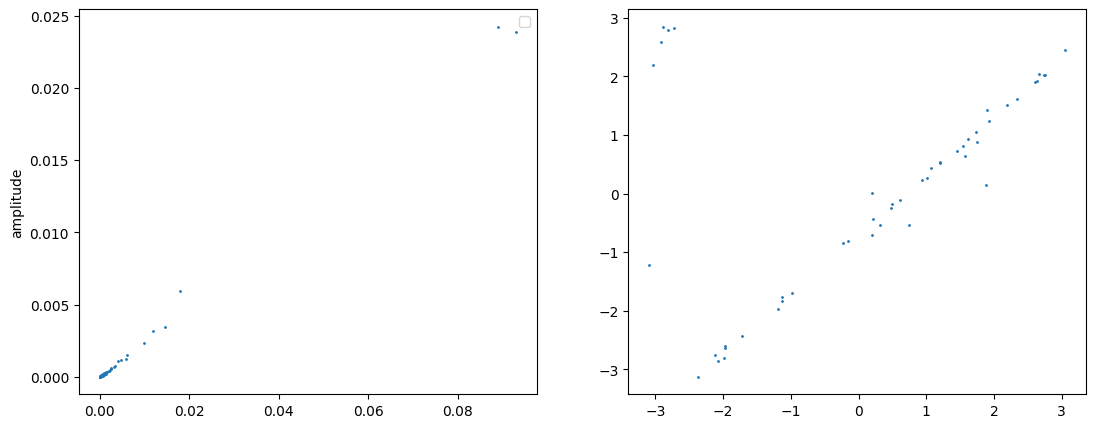

In [45]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
ax1.scatter(np.abs(pressure_target), np.abs(velocity_target), s=1)
ax1.set_ylabel("amplitude")
ax1.legend()
ax2.scatter(np.angle(pressure_target), np.angle(velocity_target), s=1)
plt.plot()